# Assignment 10 - NLP with Deep Learning

## Why This Matters
This assignment gives you hands-on experience with:
- How machines represent word meaning (embeddings)
- Embedding-based retrieval
- Modern text classification techniques
- Comparing rule-based vs learned approaches

Most of the code is directly executable. You only need to implement one simple function for retrieval.

## Environment Setup
*Optimized for Colab - minimal installations*

In [1]:
!pip install -q nltk gensim
try:
    import torch, transformers, datasets
    print(f"Torch: {torch.__version__}")
    print(f"Transformers: {transformers.__version__}")
    print(f"Datasets: {datasets.__version__}")
except ImportError:
    # !pip install -q torch>=2.1 transformers>=4.40 datasets>=2.18
    !pip install -q torch==2.2.2 transformers==4.55.0 datasets>=2.18
!pip install -q evaluate


Torch: 2.2.2
Transformers: 4.55.0
Datasets: 2.19.2


In [2]:
# Additional requirements
try:
    import nltk, gensim
except ImportError:
    !pip install -q nltk gensim

# Task 1: Word Embeddings Playground
*Where we discover words live in math space!*

## 1.1 How Word Vectors Work
GloVe vectors are created by analyzing word co-occurrence statistics across a massive corpus. Each dimension captures latent semantic features - for example:
- Dimension 12 might represent "gender" (king→queen)
- Dimension 47 might encode "plurality"

The values shown in our plot are these learned feature weights.

In [3]:
# !pip install -q matplotlib
import gensim.downloader as api
import matplotlib.pyplot as plt

# Load embeddings (like digital dictionaries)
print("Available embeddings:", list(api.info()['models'].keys()))
glove = api.load("glove-wiki-gigaword-300")

Available embeddings: ['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


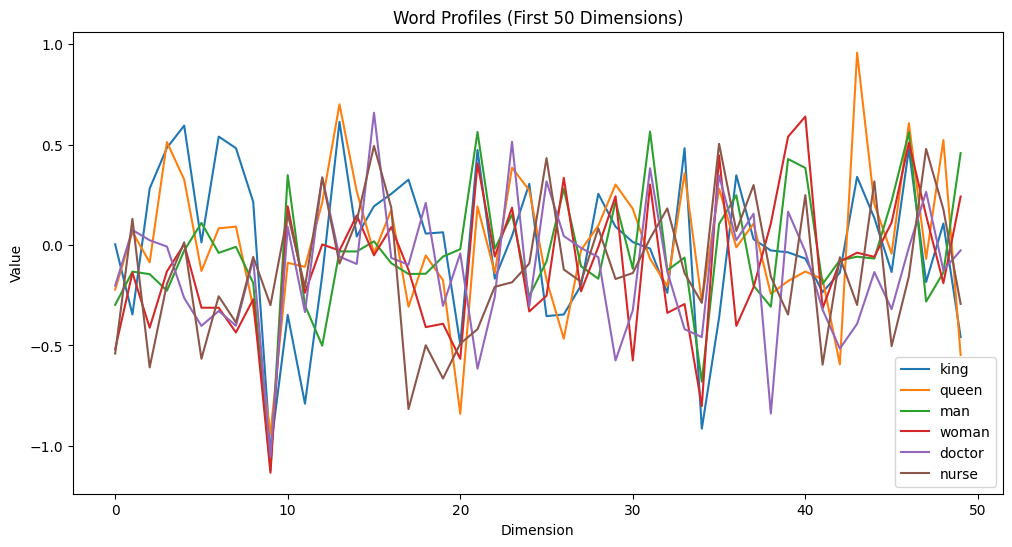

In [3]:
# Fun visualization
words = ["king", "queen", "man", "woman", "doctor", "nurse"]
plt.figure(figsize=(12,6))
for word in words:
    plt.plot(glove[word][:50], label=word)
plt.title("Word Profiles (First 50 Dimensions)")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.legend()
plt.show()

## 1.2 Word Relationships Game
Let's solve analogies like word puzzles!

### Why Analogies Work Mathematically
When we compute `king - man + woman ≈ queen`, we're essentially:
1. Removing the "maleness" vector component
2. Adding "femaleness"
3. Searching for the closest matching vector in the embedding space
This works because relationships are preserved as linear translations in the vector space.

In [4]:
def word_math(a, b, c, top_n=3):
    """Solves a is to b as c is to ___"""
    try:
        results = glove.most_similar(positive=[c, b], negative=[a], topn=top_n)
        print(f"\n{a} → {b} :: {c} → ?")
        for word, score in results:
            print(f"- {word} (confidence: {score:.2f})")
    except KeyError as e:
        print(f"Oops! Missing word: {e}")

**Please try:** Use the `word_math()` function with at least 2 new examples of your choice.

**Please answer:** Did your results make sense? What relationships did the model capture?

In [8]:
word_math("good", "better", "bad")


good → better :: bad → ?
- worse (confidence: 0.74)
- things (confidence: 0.57)
- gotten (confidence: 0.56)


In [7]:
word_math("walk", "walking", "swim")


walk → walking :: swim → ?
- swimming (confidence: 0.68)
- swam (confidence: 0.57)
- biking (confidence: 0.52)


## Reflection
- How do word embeddings like GloVe help in understanding relationships between words?
- Can you think of other applications where word vectors could be useful?

## 1.3 Semantic Retrieval with Sentence Embeddings

In this mini-task, you will explore how different text representations affect retrieval quality on hotel reviews. We will use a subset of the `Aditya1010/17k-hotel-reviews-dataset` and a pretrained sentence embedding model such as `all-MiniLM-L6-v2`.

Given a query (a hotel review or a user's requirement on the hotel), retrieve the top 3 most similar reviews (based on cosine similarity) from the dataset using:

* TF-IDF vectors
* Sentence embeddings

Then compare the results from the two methods.

### Install nessary libraries and load the dataset 

In [1]:
# !pip install datasets scikit-learn pandas numpy # if needed

import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# !pip install sentence-transformers
# !pip install "numpy<2" # To avoid potential compatibility issues with newer numpy versions
from sentence_transformers import SentenceTransformer

df = pd.read_json("hotel_reviews.json", lines=True)
print(df.head())
reviews = df["clean_review"].tolist()

                                              review     label  \
0  great experience-i happy, just came yesterday,...  NEGATIVE   
1  great hotel great hotel good position san juan...  POSITIVE   
2  lovely hotel great location started week holid...  POSITIVE   
3  surprised surprised good reviews hotel got, lo...  NEGATIVE   
4  trouble paradise read review, traveled excelle...  NEGATIVE   

                                        clean_review  word_count  
0  great experience-i happy, just came yesterday,...          97  
1  great hotel great hotel good position san juan...         107  
2  lovely hotel great location started week holid...          84  
3  surprised surprised good reviews hotel got, lo...          35  
4  trouble paradise read review, traveled excelle...         128  


### Build TF-IDF index

In [2]:
 
# Basic TF-IDF Vectorization, used unigrams, bigrams, and trigrams, and limited to top 16k features
# You can adjust max_features and ngram_range
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=16384,
    ngram_range=(1, 3)
)

tfidf_matrix = tfidf.fit_transform(reviews)
tfidf_matrix.shape

(2000, 16384)

In [3]:
# TODO: Implement the retrieval function using TF-IDF and cosine similarity
# Return the top-k most similar reviews for a given query
# results is a list of dictionaries in the format of {"review": review_text, "score": similarity_score}
# Exclude the query review itself if the query is taken from the dataset.

def retrieve_tfidf(query, reviews, tfidf_vectorizer, tfidf_matrix, k=3):
    query_vec = tfidf_vectorizer.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).ravel()
    ranked_indices = scores.argsort()[::-1]

    results = []
    for idx in ranked_indices:
        if reviews[idx].strip() == query.strip():
            continue
        results.append({"review": reviews[idx], "score": float(scores[idx])})
        if len(results) == k:
            break

    return results

### Sentence embedding retrieval
Encode reviews with sentence embeddings

In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")
review_embeddings = model.encode(reviews, convert_to_numpy=True, show_progress_bar=True)
review_embeddings.shape

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

(2000, 384)

In [5]:
# TODO: Implement the retrieval function using sentence embeddings and cosine similarity
# Return the top-k most similar reviews for a given query
# results is a list of dictionaries in the format of {"review": review_text, "score": similarity_score}
# Exclude the query review itself if the query is taken from the dataset.

def retrieve_embeddings(query, reviews, model, review_embeddings, k=3):
    query_embedding = model.encode([query], convert_to_numpy=True)
    scores = cosine_similarity(query_embedding, review_embeddings).ravel()
    ranked_indices = scores.argsort()[::-1]

    results = []
    for idx in ranked_indices:
        if reviews[idx].strip() == query.strip():
            continue
        results.append({"review": reviews[idx], "score": float(scores[idx])})
        if len(results) == k:
            break

    return results

In [6]:
# Example queries to test the retrieval functions
queries = [
    "Rooms were clean and in good condition. All amenities were in working condition.",
    "Breakfast was disappointing, but the staff were friendly and helpful.",
    "The room was small but very clean and quiet at night.",
    "The location was convenient, but the room felt kind of outdated.",
    "Want to find a hotel with excellent service and spacious, spotless rooms.",
]

# Display results
for q in queries:
    print("=" * 100)
    print("QUERY:")
    print(q)
    print("\nTF-IDF RESULTS:")
    for i, res in enumerate(retrieve_tfidf(q, reviews, tfidf, tfidf_matrix, k=3), 1):
        print(f"{i}. score={res['score']:.4f}")
        print(res["review"])
        print()

    print("EMBEDDING RESULTS:")
    for i, res in enumerate(retrieve_embeddings(q, reviews, model, review_embeddings, k=3), 1):
        print(f"{i}. score={res['score']:.4f}")
        print(res["review"])
        print()

QUERY:
Rooms were clean and in good condition. All amenities were in working condition.

TF-IDF RESULTS:
1. score=0.8267
Rooms were clean and in good condition. All amenities were in working condition. Excellent service from the housekeeping department. … Read more

2. score=0.3446
The rooms are not in good condition. 200% need maintainance . Floor is too dirty with stains .it was like 3star run down preoperty anmbience . Unless upgraded can look for another option . …

3. score=0.3251
Rooms are not clean. The bedsheet, blanket, towel and curtains were very dirty. Bathroom accessories were also in very poor condition. The charge OYO or hotel owner takes is of 3 stars hotel. But the condition of hotel is not even of 1star. … Read more

EMBEDDING RESULTS:
1. score=0.9214
Rooms were clean and in good condition. All amenities were in working condition. Excellent service from the housekeeping department. … Read more

2. score=0.6994
The rooms were very neat and clean. The old architecture o

### Questions
Compare the top-3 results from TF-IDF and sentence embeddings for at least three queries (you may add your own made-up queries).
**Please answer:** 
1. Give one example where TF-IDF retrieved reviews with high word overlap but weaker semantic similarity.
2. Give one example where sentence embeddings retrieved a semantically similar review with different wording.
3. In a hotel-review search system, when will embedding-based retrieval be more useful than keyword matching?

---
# Task 2: Sentiment Analysis Battle
*LSTMs vs Transformers vs Rule-Based*

## 2.1 Data Loading
*Stanford Sentiment Treebank - movie reviews*


📌 Tokenize SST2 and build word-level vocab

In [25]:
from datasets import load_dataset
from collections import Counter
from nltk.tokenize import word_tokenize
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/parkjoohyun/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/parkjoohyun/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [26]:
# Load SST2
raw_sst2 = load_dataset("glue", "sst2")

In [27]:
# Tokenize
def tokenize(example):
    return {"tokens": word_tokenize(example["sentence"].lower())}

In [28]:
tokenized = raw_sst2["train"].map(tokenize)
tokenized_val = raw_sst2["validation"].map(tokenize)

In [29]:
# Build vocab
word_counts = Counter(word for ex in tokenized["tokens"] for word in ex)
vocab = {"<pad>": 0, "<unk>": 1}
for word, count in word_counts.items():
    if count >= 2:
        vocab[word] = len(vocab)
print(f"Vocab size: {len(vocab)}")

Vocab size: 14301


### The Role of Attention Masks
These binary tensors tell the model which tokens are:
- `1`: Actual content
- `0`: Padding (empty space added for batch uniformity)
Without them, the model would process padding as meaningful input!

## 2.2 LSTM Model
*Our trusty recurrent network*

### Why LSTMs for Text?
Long Short-Term Memory networks:
- Maintain a "memory cell" that tracks sentence context
- Use gates to control information flow (forget/update/output)
- Particularly good at capturing negation (e.g., "not good")

📌 Load GloVe vectors and build embedding matrix

In [30]:
import gensim.downloader as api
import numpy as np

In [31]:
try:
  glove
except:
  glove = api.load("glove-wiki-gigaword-300")

In [32]:
embedding_dim = 300
embedding_matrix = np.random.normal(scale=0.6, size=(len(vocab), embedding_dim)).astype(np.float32)

In [33]:
hits = 0
for word, idx in vocab.items():
    if word in glove:
        embedding_matrix[idx] = glove[word]
        hits += 1
print(f"GloVe coverage: {hits}/{len(vocab)} = {100 * hits/len(vocab):.2f}%")

GloVe coverage: 13303/14301 = 93.02%


📌 Prepare dataset and DataLoader

In [34]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

In [35]:
def encode(tokens):
    return [vocab.get(token, vocab["<unk>"]) for token in tokens]

In [36]:
def collate(batch):
    input_ids = [torch.tensor(encode(ex["tokens"])) for ex in batch]
    labels = torch.tensor([ex["label"] for ex in batch])
    return pad_sequence(input_ids, batch_first=True, padding_value=vocab["<pad>"]), labels

In [37]:
# Use a small subset for quick training
train_data = tokenized.select(range(5000))
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate)
val_data = tokenized_val
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, collate_fn=collate)


### LSTM Model Definition
*Defining the architecture of our LSTM model using GloVe embeddings*

In [38]:
import torch.nn as nn

In [39]:
class GloveLSTM(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        num_embeddings, emb_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix), freeze=False, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, 128, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        h = torch.cat((h_n[0], h_n[1]), dim=1)
        return self.fc(h)

### Training the LSTM Model
📌 Train the LSTM with classic PyTorch

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GloveLSTM(embedding_matrix).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

In [24]:
for epoch in range(5):
    total_loss = 0
    correct = 0
    total = 0
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    print(f"Epoch {epoch+1} | training | Loss: {total_loss:.2f} | Accuracy: {100 * correct/total:.2f}%")
    
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    print(f"Validation | Loss: {total_loss:.2f} | Accuracy: {100 * correct/total:.2f}%")

Epoch 1 | training | Loss: 79.93 | Accuracy: 74.50%
Validation | Loss: 14.06 | Accuracy: 75.80%
Epoch 2 | training | Loss: 41.38 | Accuracy: 89.30%
Validation | Loss: 14.14 | Accuracy: 78.44%
Epoch 3 | training | Loss: 22.14 | Accuracy: 94.68%
Validation | Loss: 21.24 | Accuracy: 75.46%
Epoch 4 | training | Loss: 11.34 | Accuracy: 97.56%
Validation | Loss: 25.09 | Accuracy: 75.80%
Epoch 5 | training | Loss: 5.93 | Accuracy: 98.78%
Validation | Loss: 31.87 | Accuracy: 72.82%


In [25]:
torch.save(model.state_dict(), "glove_lstm.pt")

Write your answers directly in this cell.
**Please answer:** 
1. What was the final training accuracy of your LSTM model?
2. At which epoch did the model start performing well?

## 2.3 Transformer Model (RoBERTa) using HuggingFace Trainer
Finetuning RoBERTa with HuggingFace Trainer API

In [1]:
#! pip install "accelerate>=0.26.0" # if needed
from datasets import load_dataset
from transformers import AutoTokenizer
from collections import Counter

In [2]:
# Load dataset and tokenizer
sst2 = load_dataset("glue", "sst2")
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

In [3]:
# Select training subset
small_train = sst2["train"].shuffle(seed=42).select(range(2000))
val_data = sst2["validation"]

In [4]:
# Define tokenizer function
def tokenize(batch):
    return tokenizer(batch["sentence"], padding="max_length", truncation=True, max_length=128)

In [5]:
# Apply tokenizer to both sets
small_train = small_train.map(tokenize, batched=True)
val_data = val_data.map(tokenize, batched=True)

In [6]:
# Check label balance BEFORE formatting
raw_labels = [ex["label"] for ex in small_train]
counts = Counter(raw_labels)
print(f"  Negative (0): {counts[0]}")
print(f"  Positive (1): {counts[1]}")

  Negative (0): 879
  Positive (1): 1121


In [7]:
# %%
# Format for PyTorch
small_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [8]:
from transformers import RobertaForSequenceClassification, TrainingArguments, Trainer
import evaluate

In [9]:
# Load model with label mapping
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1}
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
# Load evaluation metric
accuracy = evaluate.load("accuracy")

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

### Fast Training Config
*Setting up the training arguments for RoBERTa*

In [12]:
# Fast training config
training_args = TrainingArguments(
    output_dir="./roberta-finetuned",
    eval_strategy="epoch",  # ensure evaluations happen regularly
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    logging_steps=10,
    logging_dir="./logs",
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to="none"
)

In [13]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=val_data,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/var/folders/hf/ndbx766s1wz64f0tzx4x6fb40000gn/T/ipykernel_70158/1391510213.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [14]:
### Training the RoBERTa model and saving the results
trainer.train()
trainer.save_model("./roberta-finetuned")
tokenizer.save_pretrained("./roberta-finetuned")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.474200,0.336962,0.881881
2,0.312600,0.328642,0.883028


('./roberta-finetuned/tokenizer_config.json',
 './roberta-finetuned/special_tokens_map.json',
 './roberta-finetuned/vocab.json',
 './roberta-finetuned/merges.txt',
 './roberta-finetuned/added_tokens.json',
 './roberta-finetuned/tokenizer.json')

**Please answer:** What was the final validation accuracy of your RoBERTa model?  
**Please answer:** Did it outperform the LSTM? Why or why not?

## 2.4 Comparison

No need to read about the rule-based classifier, just for your reference: [VADER github link](https://github.com/cjhutto/vadersentiment).


### Rule-Based vs Learned Sentiment Analysis
| Approach      | Strengths                          | Weaknesses                     |
|---------------|------------------------------------|--------------------------------|
| VADER         | Fast, no training needed           | Handles only simple patterns   |
| LSTM          | Learns complex phrasing            | Needs lots of data             |
| Transformer   | Captures long-range dependencies   | Computationally expensive      |

In [15]:
# ✅ Ground truth labels for each input
# 0 = negative, 1 = positive
# Feel free to add your tests
example_data = [
    ("This movie was fantastic!", 1),
    ("¡Esta película fue horrible!", 0),
    ("Ce film était très bon.", 1),
    ("Der Film war wirklich schlecht.", 0),
    ("This was just okay.", 1),
    ("I wish I had quit Marvel before seeing this.", 0)
]

In [41]:
# Make sure these are run earlier:
# - embedding_matrix and vocab must exist
# - GloveLSTM class must be defined
# - example_data = [(text, label), ...] must be set

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import RobertaForSequenceClassification, AutoTokenizer, pipeline
import torch
import torch.nn.functional as F
from nltk.tokenize import word_tokenize
import pandas as pd

# Initialize VADER
nltk.download('vader_lexicon')
vader = SentimentIntensityAnalyzer()

# Load LSTM model
lstm_model = GloveLSTM(embedding_matrix)
lstm_model.load_state_dict(torch.load("glove_lstm.pt", map_location="cpu"))
lstm_model.eval()

# Load RoBERTa model and pipeline
roberta_model = RobertaForSequenceClassification.from_pretrained("./roberta-finetuned")
roberta_tokenizer = AutoTokenizer.from_pretrained("./roberta-finetuned")
roberta_pipe = pipeline("sentiment-analysis", model=roberta_model, tokenizer=roberta_tokenizer)

# Compare models on predefined data
rows = []
for text, true_label in example_data:
    # VADER
    vader_score = vader.polarity_scores(text)["compound"]
    vader_pred = 1 if vader_score > 0.05 else 0 if vader_score < -0.05 else -1
    vader_label = {1: "positive", 0: "negative", -1: "neutral"}[vader_pred]
    vader_correct = "✅" if vader_pred == true_label else "❌"

    # LSTM
    tokens = [vocab.get(tok.lower(), vocab["<unk>"]) for tok in word_tokenize(text)]
    input_tensor = torch.tensor(tokens).unsqueeze(0)
    with torch.no_grad():
        logits = lstm_model(input_tensor)
        probs = F.softmax(logits, dim=1).squeeze()
        lstm_pred = int(probs.argmax().item())
        lstm_conf = probs.max().item()
    lstm_label = "positive" if lstm_pred == 1 else "negative"
    lstm_correct = "✅" if lstm_pred == true_label else "❌"

    # RoBERTa
    roberta_result = roberta_pipe(text)[0]
    roberta_label = roberta_result["label"].lower()
    roberta_pred = 1 if roberta_label == "positive" else 0
    roberta_conf = roberta_result["score"]
    roberta_correct = "✅" if roberta_pred == true_label else "❌"

    rows.append({
        "Text": text,
        "True": "positive" if true_label else "negative",
        "VADER": f"{vader_label} {vader_correct}",
        "LSTM": f"{lstm_label} ({lstm_conf:.2f}) {lstm_correct}",
        "RoBERTa": f"{roberta_label} ({roberta_conf:.2f}) {roberta_correct}"
    })

# Display as table
pd.DataFrame(rows)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/parkjoohyun/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
Device set to use mps:0


,Text,True,VADER,LSTM,RoBERTa
0,This movie was fantastic!,positive,positive ✅,positive (1.00) ✅,positive (0.97) ✅
1,¡Esta película fue horrible!,negative,negative ✅,negative (0.97) ✅,negative (0.89) ✅
2,Ce film était très bon.,positive,neutral ❌,positive (0.81) ✅,positive (0.65) ✅
3,Der Film war wirklich schlecht.,negative,negative ✅,positive (0.72) ❌,negative (0.90) ✅
4,This was just okay.,positive,positive ✅,negative (0.54) ❌,positive (0.89) ✅
5,I wish I had quit Marvel before seeing this.,negative,positive ❌,positive (0.98) ❌,negative (0.81) ✅


## 🧠 Knowledge Check

**Please answer all questions below:**

1. What are the strengths and weaknesses of using rule-based sentiment analysis compared to learned models like LSTM or RoBERTa?

2. How does the attention mechanism in Transformers improve model performance?

3. For each model, choose one example from the sentiment table where the model made a mistake. Why do you think it failed?

4. What does GloVe use to represent word meaning?

5. Why does RoBERTa outperform LSTM in some cases?

6. How does padding affect model performance?


# Submission Instructions

Please submit the following two files to Canvas:

- `A10.ipynb`: Your completed Colab or Jupyter notebook
  - Implement the two retrieval functions in 1.3
  - Must include **all output** and run top-to-bottom without error
- `answers.txt`: Since there are many questions, let's put them in one single plain text file, which contains:
  - Your answers to all **reflection and knowledge check questions**
  - Copy/paste the questions into the file before your answers
- Checklist:
    - 1.2 questions
    - 1.3 code
    - 1.3 questions
    - 2.2 questions
    - 2.3 questions
    - 2.4 questions